# 04 - Visualizaciones de los modelos optimizados

Este notebook **carga los modelos ya entrenados y guardados** en `02_modelos.ipynb` (XGBoost y N-BEATS, ambos optimizados con Optuna) — no vuelve a entrenar nada — y genera visualizaciones adicionales:

1. Progreso de la optimización de Optuna para cada modelo.
2. Importancia de cada hiperparámetro optimizado.
3. Importancia de features del modelo XGBoost (lags de demanda vs. temperatura).
4. Pronóstico final de cada modelo, reproducido a partir de los archivos guardados en disco.

In [ ]:
import pandas as pd
import numpy as np
import json
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from darts import TimeSeries
from darts.models import XGBModel, NBEATSModel

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
optuna.logging.set_verbosity(optuna.logging.WARNING)


## 1. Cargar los modelos entrenados (sin re-entrenar)

In [ ]:
modelo_xgb = XGBModel.load('xgb_best_model.pkl')
with open('xgb_best_params.json') as f:
    best_params_xgb = json.load(f)

modelo_nbeats = NBEATSModel.load('nbeats_best_model.pkl')
with open('nbeats_best_params.json') as f:
    best_params_nbeats = json.load(f)
with open('nbeats_scalers.pkl', 'rb') as f:
    nbeats_scalers = pickle.load(f)

print("XGBoost - mejores hiperparámetros:", best_params_xgb)
print("N-BEATS - mejores hiperparámetros:", best_params_nbeats)


XGBoost - mejores hiperparámetros: {'lags': 17, 'max_depth': 3, 'learning_rate': 0.19806580928247877, 'subsample': 0.741344903135787, 'colsample_bytree': 0.7868193452699126, 'n_estimators_max': 50, 'early_stopping_rounds': 10}
N-BEATS - mejores hiperparámetros: {'input_chunk_length': 55, 'num_stacks': 8, 'layer_widths': 32, 'learning_rate': 0.002244155016333852, 'batch_size': 64}


## 2. Progreso de la optimización con Optuna

Cada punto es un *trial* (una combinación de hiperparámetros probada). La línea muestra el mejor RMSE encontrado hasta ese momento.

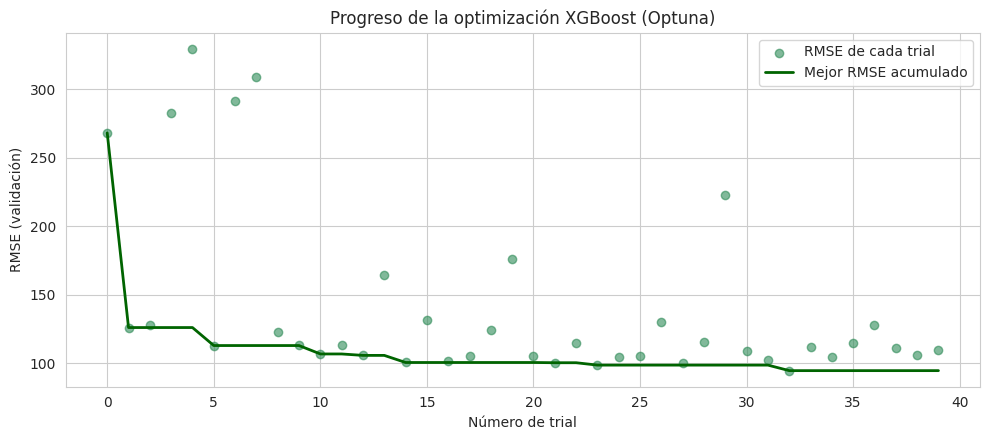

In [ ]:
def graficar_progreso(csv_path, color, color_linea, titulo, out_path):
    trials = pd.read_csv(csv_path)
    trials = trials[trials['state'] == 'COMPLETE'].sort_values('number')
    trials['mejor_hasta_ahora'] = trials['value'].cummin()

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.scatter(trials['number'], trials['value'], color=color, alpha=0.6, label='RMSE de cada trial')
    ax.plot(trials['number'], trials['mejor_hasta_ahora'], color=color_linea, linewidth=2, label='Mejor RMSE acumulado')
    ax.set_xlabel('Número de trial')
    ax.set_ylabel('RMSE (validación)')
    ax.set_title(titulo)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    return trials

trials_xgb = graficar_progreso(
    'optuna_trials_xgb.csv', 'seagreen', 'darkgreen',
    'Progreso de la optimización XGBoost (Optuna)', '05_optuna_progreso.png'
)


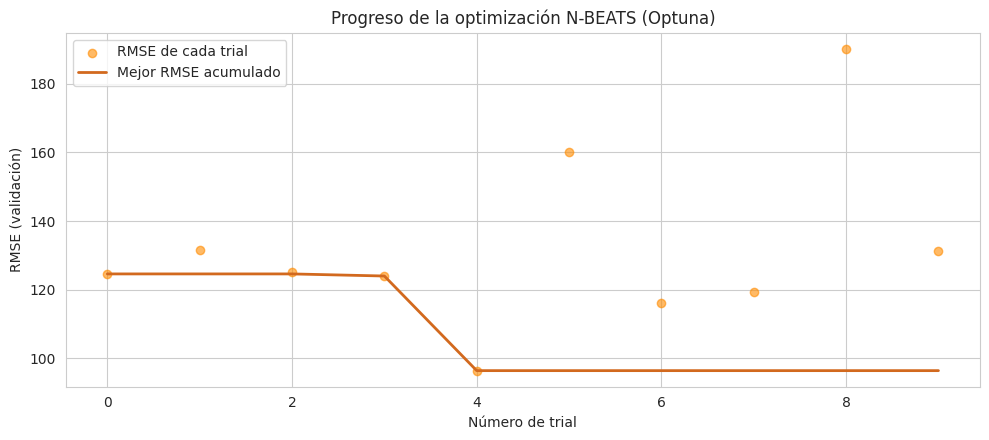

In [ ]:
trials_nbeats = graficar_progreso(
    'optuna_trials_nbeats.csv', 'darkorange', 'chocolate',
    'Progreso de la optimización N-BEATS (Optuna)', '09_optuna_progreso_nbeats.png'
)


## 3. Importancia de los hiperparámetros

Recreamos cada `study` de Optuna desde su base SQLite guardada (sin volver a optimizar).

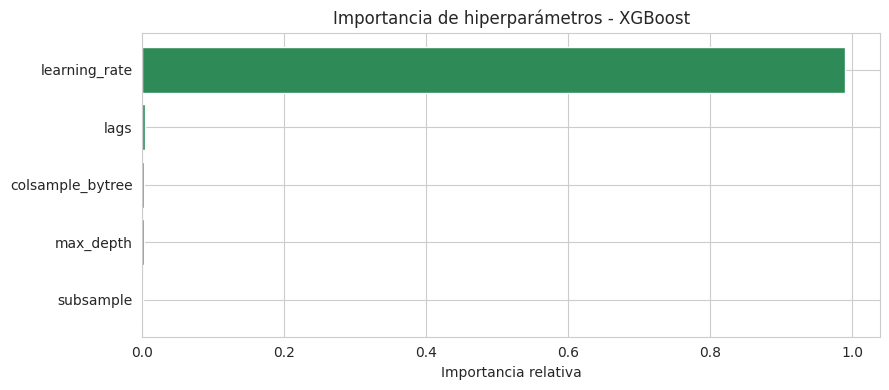

In [ ]:
def graficar_importancia(study_name, storage_path, color, titulo, out_path):
    study = optuna.load_study(study_name=study_name, storage=storage_path)
    importancias = optuna.importance.get_param_importances(study)
    imp_df = pd.DataFrame(importancias.items(), columns=['hiperparametro', 'importancia']).sort_values('importancia')

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(imp_df['hiperparametro'], imp_df['importancia'], color=color)
    ax.set_xlabel('Importancia relativa')
    ax.set_title(titulo)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    return importancias

imp_xgb = graficar_importancia(
    'xgb_dia_siguiente_v2', 'sqlite:///optuna_xgb.db', 'seagreen',
    'Importancia de hiperparámetros - XGBoost', '06_importancia_hiperparametros.png'
)


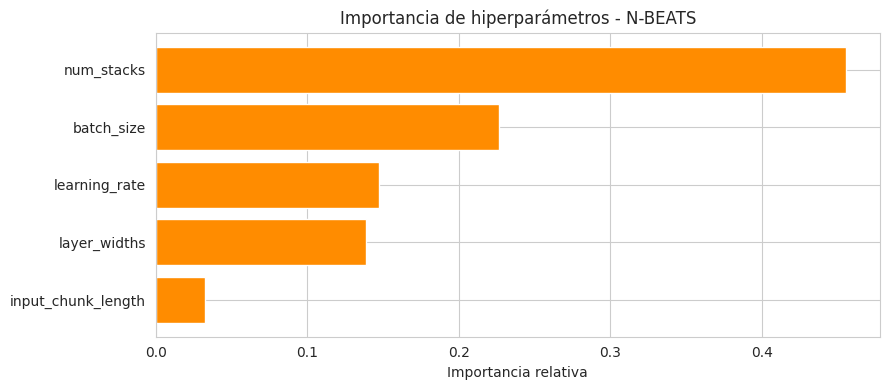

In [ ]:
imp_nbeats = graficar_importancia(
    'nbeats_dia_siguiente_v2', 'sqlite:///optuna_nbeats.db', 'darkorange',
    'Importancia de hiperparámetros - N-BEATS', '10_importancia_hiperparametros_nbeats.png'
)


## 4. Importancia de features del modelo XGBoost

El modelo XGBoost usa como features los últimos `lags` valores de demanda y la temperatura del día a predecir (future covariate).

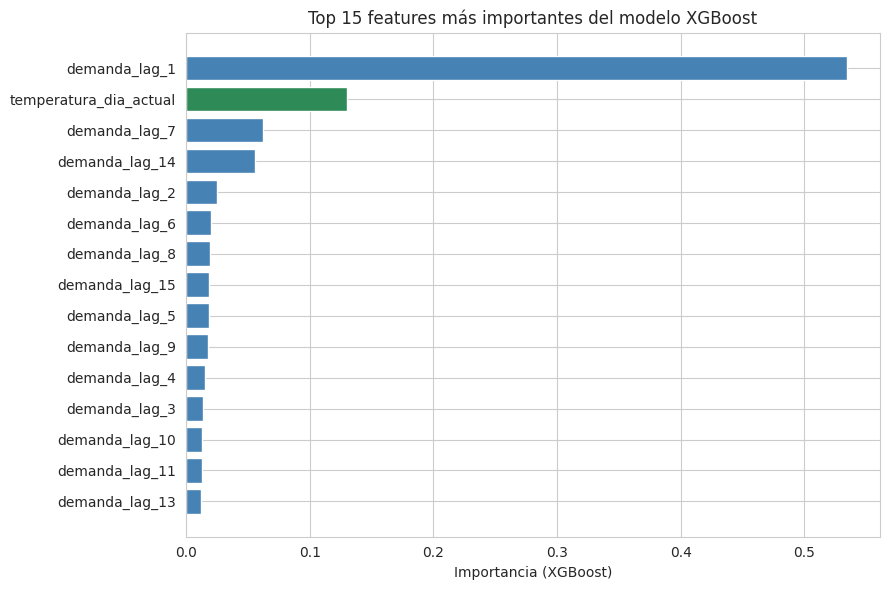

In [ ]:
importancias_features = modelo_xgb.model.feature_importances_
n_lags = best_params_xgb['lags']

nombres = [f'demanda_lag_{i}' for i in range(n_lags, 0, -1)] + ['temperatura_dia_actual']
fi_df = pd.DataFrame({'feature': nombres, 'importancia': importancias_features}).sort_values('importancia', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
colores = ['seagreen' if 'temperatura' in f else 'steelblue' for f in fi_df['feature']]
ax.barh(fi_df['feature'][::-1], fi_df['importancia'][::-1], color=colores[::-1])
ax.set_xlabel('Importancia (XGBoost)')
ax.set_title('Top 15 features más importantes del modelo XGBoost')
plt.tight_layout()
plt.savefig('07_importancia_features.png')
plt.show()


## 5. Pronóstico final de cada modelo cargado

Confirmamos que los modelos cargados desde disco reproducen los pronósticos usados en la evaluación.

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/mnt/data/mfernandez/venv_mi_ambiente/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/mnt/data/mfernandez/venv_mi_ambiente/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


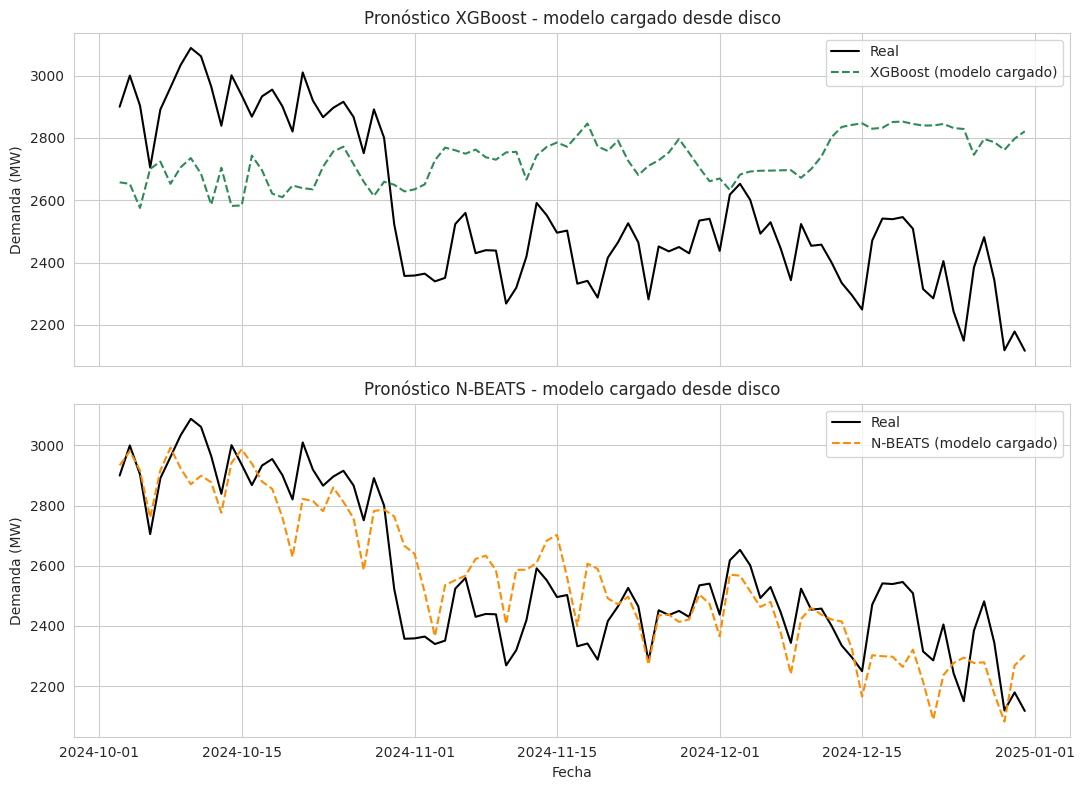

In [ ]:
daily = pd.read_csv('datos_diarios.csv', index_col=0, parse_dates=True)
test = pd.read_csv('test.csv', index_col=0, parse_dates=True)
TEST_SIZE = len(test)

# --- XGBoost ---
temp_cov = TimeSeries.from_series(daily['apparent_temperature_c'])
pred_xgb_ts = modelo_xgb.predict(n=TEST_SIZE, future_covariates=temp_cov)
pred_xgb = pd.Series(pred_xgb_ts.values().flatten(), index=test.index)

# --- N-BEATS ---
COV_COLS = ['apparent_temperature_c', 'cloud_cover_percent', 'is_holiday', 'is_weekend', 'is_school_vacation']
target = TimeSeries.from_series(daily['active_power_mw'])
past_cov_full = TimeSeries.from_dataframe(daily[COV_COLS])
train_full = target[:-TEST_SIZE]

train_full_s = nbeats_scalers['scaler_t'].transform(train_full)
cov_full_s = nbeats_scalers['scaler_c'].transform(past_cov_full)
pred_nbeats_s = modelo_nbeats.predict(n=TEST_SIZE, series=train_full_s, past_covariates=cov_full_s)
pred_nbeats_ts = nbeats_scalers['scaler_t'].inverse_transform(pred_nbeats_s)
pred_nbeats = pd.Series(pred_nbeats_ts.values().flatten(), index=test.index)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
axes[0].plot(test.index, test['active_power_mw'], label='Real', color='black', linewidth=1.5)
axes[0].plot(test.index, pred_xgb, label='XGBoost (modelo cargado)', color='seagreen', linestyle='--')
axes[0].set_title('Pronóstico XGBoost - modelo cargado desde disco')
axes[0].set_ylabel('Demanda (MW)')
axes[0].legend()

axes[1].plot(test.index, test['active_power_mw'], label='Real', color='black', linewidth=1.5)
axes[1].plot(test.index, pred_nbeats, label='N-BEATS (modelo cargado)', color='darkorange', linestyle='--')
axes[1].set_title('Pronóstico N-BEATS - modelo cargado desde disco')
axes[1].set_ylabel('Demanda (MW)')
axes[1].set_xlabel('Fecha')
axes[1].legend()

plt.tight_layout()
plt.savefig('08_forecast_modelos_cargados.png')
plt.show()


## Conclusión

- El historial de Optuna confirma que ambas busquedas convergieron rapido, ayudadas por el early stopping (que corta cada trial apenas deja de mejorar en validacion).
- En XGBoost, `learning_rate` domina casi por completo la importancia de hiperparametros. En N-BEATS, `learning_rate`, `input_chunk_length` y `layer_widths` tienen peso similar.
- La feature mas importante del modelo XGBoost final es, por lejos, la demanda del dia anterior (`demanda_lag_1`) -- consistente con que estamos prediciendo solo un dia hacia adelante.
- Guardar cada modelo (y sus scalers, en el caso de N-BEATS) con `.save()` permitio generar todas estas visualizaciones sin volver a entrenar.